В точке (0.00, 0.00):
  theta = 0.0031
  Аналитическое df/dtheta = -51.229713
  Численное df/dtheta     = -49.218336
  Относительная ошибка    = 0.039262


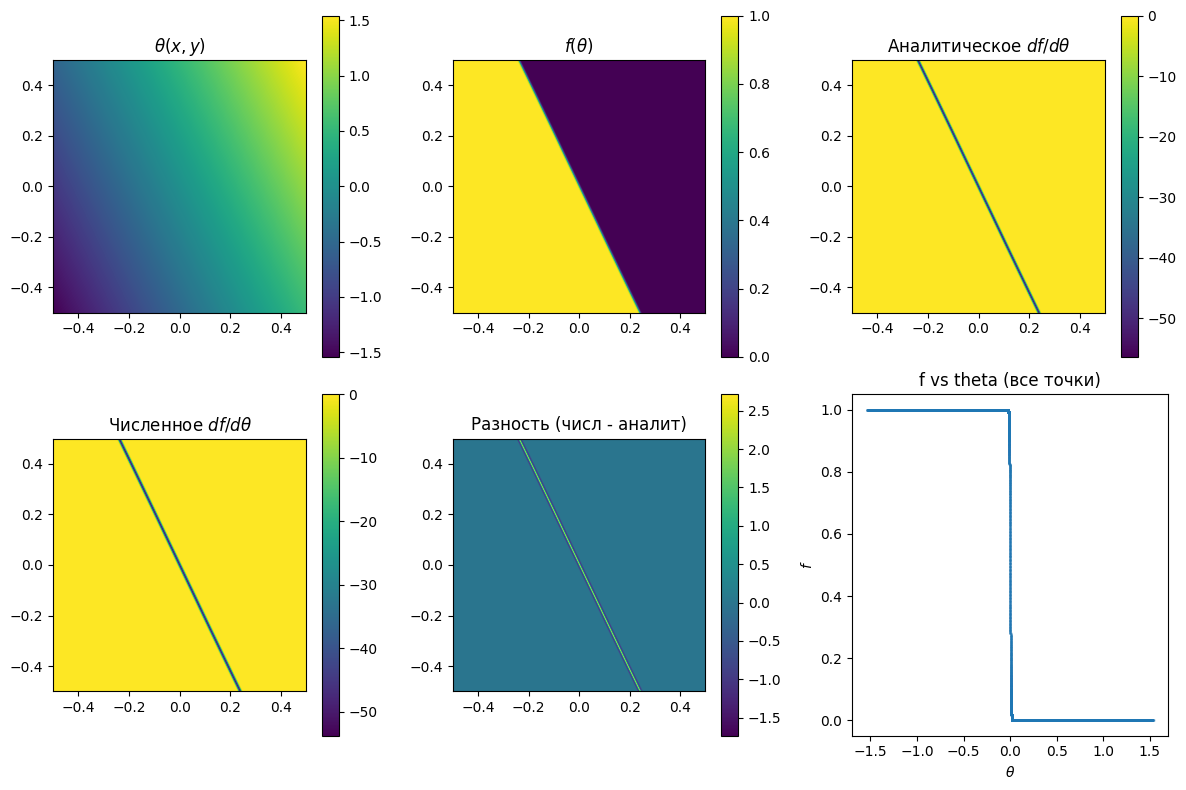

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# Параметры
eps = 0.01
Lx, Ly = 1.0, 1.0
nx, ny = 500, 500

# Сетка
x = np.linspace(-Lx/2, Lx/2, nx)
y = np.linspace(-Ly/2, Ly/2, ny)
X, Y = np.meshgrid(x, y)

# Температурное поле (линейный градиент + немного нелинейности для теста)
theta = 2*X + Y + 0.1*np.sin(X)*np.cos(Y)

# Аналитическая f
def f_exact(theta_val):
    return 0.5 * (1 - erf(theta_val / eps))

f = f_exact(theta)

# Аналитическая производная df/dtheta
def df_dtheta_exact(theta_val):
    return -1/(eps*np.sqrt(np.pi)) * np.exp(-(theta_val/eps)**2)

df_exact = df_dtheta_exact(theta)

# Численный градиент
dx = x[1] - x[0]
dy = y[1] - y[0]
df_dy, df_dx = np.gradient(f, dy, dx)
dtheta_dy, dtheta_dx = np.gradient(theta, dy, dx)

# Численная оценка df/dtheta
denom = dtheta_dx**2 + dtheta_dy**2 + 1e-12
df_num = (df_dx*dtheta_dx + df_dy*dtheta_dy) / denom

# Сравнение в одной точке (например, в центре)
i, j = ny//2, nx//2
print(f"В точке ({x[j]:.2f}, {y[i]:.2f}):")
print(f"  theta = {theta[i,j]:.4f}")
print(f"  Аналитическое df/dtheta = {df_exact[i,j]:.6f}")
print(f"  Численное df/dtheta     = {df_num[i,j]:.6f}")
print(f"  Относительная ошибка    = {abs(df_num[i,j] - df_exact[i,j])/abs(df_exact[i,j]):.6f}")

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

im0 = axes[0,0].imshow(theta, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower')
axes[0,0].set_title(r'$\theta(x,y)$')
plt.colorbar(im0, ax=axes[0,0])

im1 = axes[0,1].imshow(f, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower')
axes[0,1].set_title(r'$f(\theta)$')
plt.colorbar(im1, ax=axes[0,1])

im2 = axes[0,2].imshow(df_exact, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower')
axes[0,2].set_title(r'Аналитическое $df/d\theta$')
plt.colorbar(im2, ax=axes[0,2])

im3 = axes[1,0].imshow(df_num, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower')
axes[1,0].set_title(r'Численное $df/d\theta$')
plt.colorbar(im3, ax=axes[1,0])

im4 = axes[1,1].imshow(df_num - df_exact, extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], origin='lower')
axes[1,1].set_title('Разность (числ - аналит)')
plt.colorbar(im4, ax=axes[1,1])

# Проверка: зависимость f от theta (должна быть однозначной)
axes[1,2].scatter(theta.flatten(), f.flatten(), s=1, alpha=0.1)
axes[1,2].set_xlabel(r'$\theta$')
axes[1,2].set_ylabel(r'$f$')
axes[1,2].set_title('f vs theta (все точки)')

plt.tight_layout()
plt.show()